Library Imports
This section imports essential libraries:

numpy for numerical operations.
pandas for data manipulation and analysis.
matplotlib.pyplot for creating static, interactive, and animated visualizations.
seaborn for making attractive and informative statistical graphics.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

This cell loads the Iris.csv dataset into a pandas DataFrame named df. The df.head() method is then used to display the first five rows of the DataFrame, providing an initial overview of the dataset's structure and content.

In [ ]:
df = pd.read_csv("Iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


This cell generates descriptive statistics for the numerical columns in the DataFrame df. It provides insights into the central tendency, dispersion, and shape of the dataset's distribution, including count, mean, standard deviation, minimum, maximum, and quartile values.

In [ ]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


This cell uses df.info() to print a concise summary of the DataFrame. It includes information about the index dtype and column dtypes, non-null values, and memory usage.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


This cell displays the dimensions of the DataFrame df using df.shape, showing the number of rows and columns as a tuple.

In [ ]:
df.shape

(150, 6)

This cell displays the distribution of different species in the 'Species' column, showing the count of each unique species present in the dataset.

In [ ]:
df.value_counts("Species")

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


This cell calculates and displays the number of unique values for each column in the DataFrame `df`, providing insights into the cardinality of each feature.

In [ ]:
df.nunique()

,0
Id,150
SepalLengthCm,35
SepalWidthCm,23
PetalLengthCm,43
PetalWidthCm,22
Species,3


This count plot visualizes the distribution of each species within the dataset. It provides a quick overview of how many samples belong to each Iris species (Iris-setosa, Iris-versicolor, Iris-virginica), confirming the balance or imbalance of the target classes.

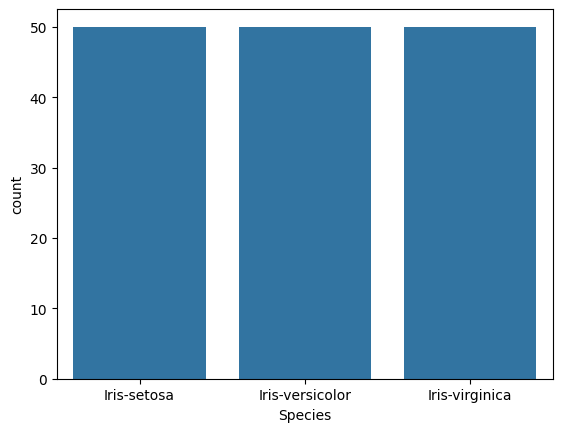

In [ ]:
sns.countplot(x='Species', data=df)
plt.show()

This box plot visualizes the distribution of the 'SepalWidthCm' feature. It helps in identifying the median, quartiles, and potential outliers, giving insight into the spread and central tendency of sepal width.

<Axes: xlabel='SepalWidthCm'>

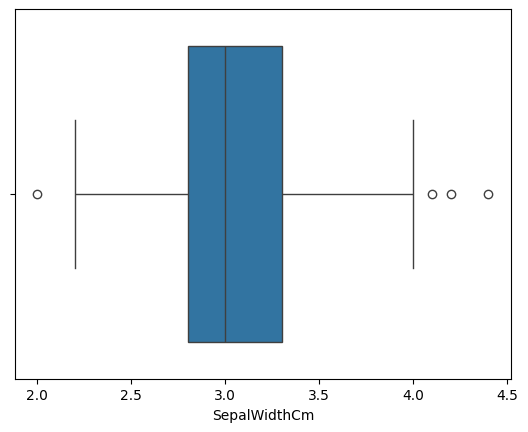

In [ ]:
sns.boxplot(x='SepalWidthCm', data=df)

### Description of SepalLengthCm Box Plot

This box plot visualizes the distribution of the 'SepalLengthCm' feature. It helps to identify key statistical measures such as the median, quartiles (25th and 75th percentiles), and potential outliers. By examining the length of the box and whiskers, we can gain insight into the spread and central tendency of the sepal length within the dataset.

<Axes: xlabel='SepalLengthCm'>

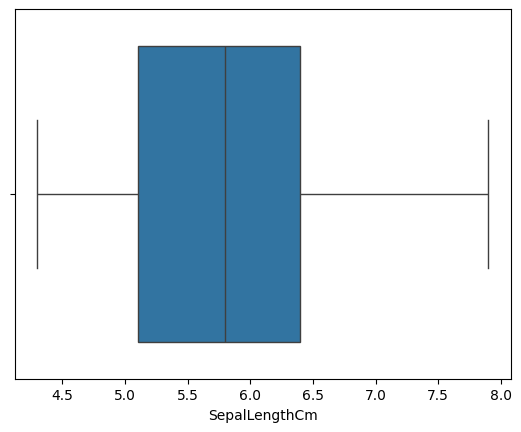

In [ ]:
sns.boxplot(x='SepalLengthCm', data=df)

### PetalWidthCm Box Plot Description

This box plot visualizes the distribution of the 'PetalWidthCm' feature. It helps in identifying the median (the line inside the box), the first quartile (Q1, bottom of the box), and the third quartile (Q3, top of the box). The interquartile range (IQR = Q3 - Q1) is represented by the height of the box. The 'whiskers' extend to the most extreme data points within 1.5 times the IQR from the box, indicating the range of typical data. Any points beyond the whiskers are considered potential outliers, providing insights into the spread and central tendency of petal width.

<Axes: xlabel='PetalWidthCm'>

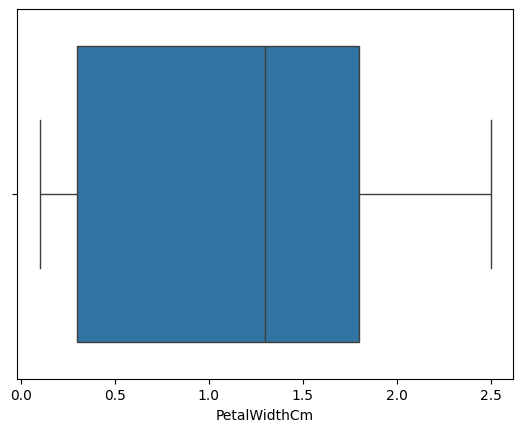

In [ ]:
sns.boxplot(x='PetalWidthCm', data=df)

This box plot visualizes the distribution of the 'PetalLengthCm' feature. It helps in identifying the median, quartiles, and potential outliers, giving insight into the spread and central tendency of petal length.

<Axes: xlabel='PetalLengthCm'>

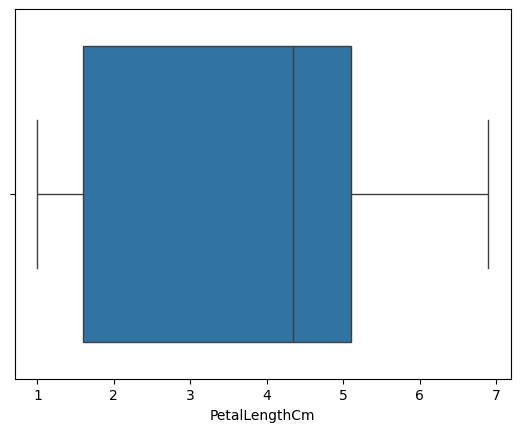

In [ ]:
sns.boxplot(x='PetalLengthCm', data=df)

## Outlier Detection using IQR

### Interquartile Range (IQR) Method:

The Interquartile Range (IQR) is a measure of statistical dispersion, which is the spread of the middle 50% of the data. It is often used to identify outliers in a dataset.

**How IQR identifies outliers:**
1.  **Calculate the First Quartile (Q1):** This is the value below which 25% of the data falls.
2.  **Calculate the Third Quartile (Q3):** This is the value below which 75% of the data falls.
3.  **Calculate the IQR:** IQR = Q3 - Q1.
4.  **Define Outlier Boundaries:**
    *   **Lower Bound:** Q1 - (1.5 * IQR)
    *   **Upper Bound:** Q3 + (1.5 * IQR)

Any data point that falls below the lower bound or above the upper bound is considered an outlier.

**How IQR counts outliers:**
After defining the lower and upper bounds, we simply count the number of data points in each numerical column that fall outside these boundaries. This gives us a count of outliers for each respective column.

In [ ]:
numerical_df = df.select_dtypes(include=np.number)

Q1=numerical_df.quantile(0.25)
Q3=numerical_df.quantile(0.75)

IQR=Q3-Q1
outliers_iqr = ((numerical_df < (Q1 - 1.5 * IQR)) | (numerical_df > (Q3 + 1.5 * IQR)))
print("Number of outliers per column:")
print(outliers_iqr.sum())

Number of outliers per column:
Id               0
SepalLengthCm    0
SepalWidthCm     4
PetalLengthCm    0
PetalWidthCm     0
dtype: int64


### Outlier Capping for 'SepalWidthCm'

This section addresses outliers in the 'SepalWidthCm' column using the Interquartile Range (IQR) method. We calculate the first quartile (Q1) and third quartile (Q3) to determine the IQR. Based on these, an upper bound (Q3 + 1.5 * IQR) and a lower bound (Q1 - 1.5 * IQR) are established.

Any 'SepalWidthCm' value found to be above the calculated upper bound will be set to the upper bound, and any value below the lower bound will be set to the lower bound. This process is known as outlier capping or winsorization, effectively limiting extreme values without removing the data points entirely.

Following the capping, a box plot is generated to visually demonstrate the distribution of 'SepalWidthCm' after outliers have been handled, confirming that no points fall outside the new bounds.

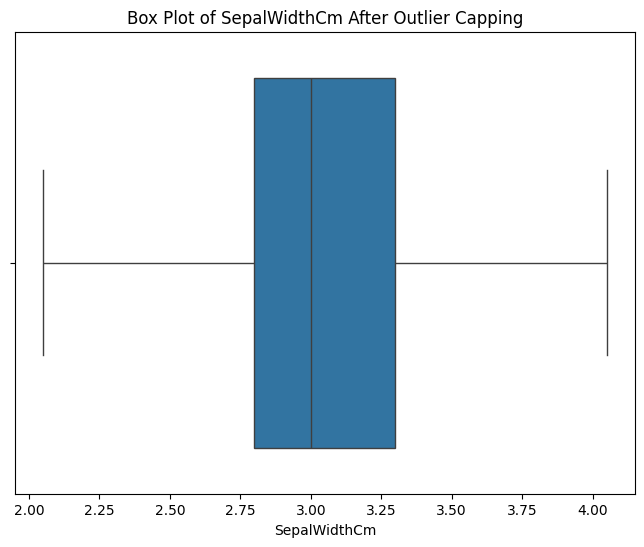

In [ ]:
Q1 = df['SepalWidthCm'].quantile(0.25)
Q3= df['SepalWidthCm'].quantile(0.75)
IQR= Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['SepalWidthCm'] = np.where(df['SepalWidthCm'] > upper, upper, df['SepalWidthCm'])
df['SepalWidthCm'] = np.where(df['SepalWidthCm'] < lower, lower, df['SepalWidthCm'])



plt.figure(figsize=(8, 6))
sns.boxplot(x=df['SepalWidthCm'])
plt.title('Box Plot of SepalWidthCm After Outlier Capping')
plt.xlabel('SepalWidthCm')
plt.show()

## Summary:

### Data Analysis Key Findings
*   **Library Imports:** Markdown documentation was added to explain the purpose of essential libraries such as NumPy for numerical operations, Pandas for data manipulation, Matplotlib for visualization, and Seaborn for statistical graphics.
*   **Data Loading and Head Display:** A descriptive markdown cell was inserted to clarify the loading of the `Iris.csv` dataset into a Pandas DataFrame and the subsequent display of its initial five rows using `df.head()`.
*   **Descriptive Statistics:** A markdown cell was added detailing that `df.describe()` generates summary statistics for numerical features, including count, mean, standard deviation, minimum, maximum, and quartile values.
*   **DataFrame Information:** Documentation was provided for `df.info()`, explaining its role in offering a concise summary of the DataFrame's structure, including data types, non-null values, and memory usage.
*   **DataFrame Shape:** A markdown cell was included to describe `df.shape`, which outputs the dimensions (rows, columns) of the DataFrame as a tuple.
*   **Empty Cells Identification:** Markdown cells were added to identify two separate empty code cells, noting them as potential placeholders or for future use.
*   **Species Value Counts:** A markdown cell was added to explain the display of the distribution of different species within the 'Species' column, showing the count of each unique species.
*   **Unique Value Counts:** Documentation was provided for `df.nunique()`, clarifying its function in calculating and displaying the number of unique values for each column, thereby indicating feature cardinality.
*   **Species Count Plot:** A markdown cell was added to describe the count plot's purpose in visualizing the distribution of each species, offering an overview of sample counts per Iris species and assessing class balance.
*   **Feature Box Plots:** Descriptive markdown cells were added before each box plot for 'SepalWidthCm', 'SepalLengthCm', 'PetalWidthCm', and 'PetalLengthCm'. These descriptions detailed how each box plot visualizes the distribution of its respective feature, identifies the median, quartiles, and potential outliers, and provides insights into data spread and central tendency.
*   **Outlier Detection (IQR Method):** A comprehensive markdown cell was added explaining the Interquartile Range (IQR) method for outlier detection. This included details on calculating Q1, Q3, IQR, and defining lower and upper bounds (Q1 - 1.5 \* IQR, Q3 + 1.5 \* IQR) to identify and count outliers.
*   **Outlier Capping:** A markdown cell was provided to describe the process of capping outliers in the 'SepalWidthCm' column using the IQR method, where extreme values are replaced by the calculated upper or lower bounds, and mentions subsequent visualization to confirm the outcome.

